<a href="https://colab.research.google.com/github/tec03/continuous_learning/blob/main/82_Bootstraping%26Ci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bootstrapping and Confidence Intervals: Measuring Uncertainty in AI Models

In [ ]:
from IPython.display import display, HTML

display(HTML("""
<div style="display:flex; justify-content:center; gap:20px; align-items:center;">

    <img src="https://raw.githubusercontent.com/tec03/Datasets/main/images/bowl_red_white.png"
         width="50%">

    <img src="https://raw.githubusercontent.com/tec03/Datasets/main/images/bowl_red_white_balllls.png"
         width="43%">

</div>
"""))

### How many red balls are in this bowl?

* red balls
* white balls


> What percentage of the balls are red?

Nobody knows.

---

Suppose I draw:

```text
20 balls  and obtain  14 red & 6 white

Estimate:

70% red
```

> Is the true percentage exactly 70%?

>> Probably not.


> Then how uncertain are we?



---

Imagine we are training an AI model.

We test it on:

```text
20 observations.  and obtain 70% accuracy
```

Same problem.

We never care only about: Accuracy = 70%

We care about:

```text
How certain is that estimate?
```

---

### The impossible problem:

> We only collected ONE sample.
>
> How can we estimate uncertainty from only one sample?

This is where bootstrap becomes magical.

---


 The key idea is: Original sample size = 20 and then, Bootstrap sample size = 20 always.
  > Why?
  > Because we want to mimic the original sampling process.

Suppose Nature gave us: 20 observations. We ask: What would happen if we repeatedly collected samples of size 20?

Since we cannot go back and collect new data, bootstrap approximates this by repeatedly sampling from the observed data.


# Bootstrap visually

Take your sample: (20 balls: 14 red, 6 white)

```text
R R R R R   R R R R R   R R R R W   W W W W W
```



Now sample with replacement.

Bootstrap sample 1: (20 balls: 18 red, 2 white)

```text
R R R R R   R R R R W   W R R R R   R R R R R
```

Bootstrap sample 2: (20 balls: 12 red, 8 white)

different composition.

Bootstrap sample 3: : (20 balls: 20 red, 0 white)

different composition.

Keep going.

---


> We are pretending that our sample is the population.

- is the heart of bootstrap.

---
---

Why do the proportions change?

- Because every bootstrap sample is a different random sample with replacement from the original sample.

Then,
  - If we repeat this 10,000 times, we obtain a distribution of possible proportions.

  >>  That transition naturally leads into the histogram.


# Now Python

Generating

```python
10000
```

bootstrap samples.

Calculate

```python
proportion_red
```

for each.

Show histogram.

Now:

> Why do some bootstrap samples give 60%?

> Why do some give 80%?

Because sampling varies.



---

# Transition to AI

Now replace

```text
proportion of red balls
```

with

```text
model accuracy
```

Exactly same procedure.

---

Suppose:

```python
accuracy = 0.83   on     200 test examples
```

Question:

> Is the real performance 83%?

No.

Bootstrap the test set.

Create:

```python
1000 resampled test sets
```

Compute accuracy each time.

Plot histogram.

Now you obtain:

```text
95% CI = [79%,87%]
```

# Confidence intervals

Model A

```text
83%  CI [79,87]
```

Model B

```text
85%  CI [81,89]
```


> Is Model B really better?


Now uncertainty becomes meaningful.

This is exactly what AI researchers face.

---

# Random Forest

> Bootstrap is not only a statistical trick.
>
> It is inside one of the most successful AI algorithms ever developed.

Show:

```text
Bootstrap sample #1  ->  Tree #1

Bootstrap sample #2  ->  Tree #2

Bootstrap sample #3  ->  Tree #3

...

Average predictions
```

Then:

```text
Random Forest = Bootstrap + Decision Trees
```

## Computer simulation of resampling

- This statistical procedure known as bootstrap resampling with replacement.

### Chief Difference Between a Bootstrap Distribution and a Sampling Distribution:

| Aspect              | **Bootstrap Distribution**                                                                                                | **Sampling Distribution**                                                                                                             |
| ------------------- | ------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| **Definition**      | Distribution of a statistic (e.g., mean, median) obtained by resampling (with replacement) from the **same sample data.** | Distribution of a statistic (e.g., mean, proportion) calculated from **multiple independent random samples** from the **population.** |
| **Source of Data**  | Derived from **one sample** by resampling (with replacement) repeatedly.                                                  | Derived from **multiple independent samples** drawn directly from the population.                                                     |
| **Purpose**         | Used to estimate the variability of a statistic (standard error, confidence intervals) without needing the population.    | Used to understand the theoretical behavior of a statistic (e.g., Central Limit Theorem).                                             |
| **Practical Usage** | Commonly used when the population distribution is unknown or when data collection is expensive.                           | Represents the theoretical behavior of a statistic across all possible samples from the population.                                   |
| **Dependence**      | Dependent on the observed sample (since resampling is from the same sample).                                              | Independent of any single sample, depends on the entire population.                                                                   |
| **Example**         | Calculating a 95% confidence interval for the mean of a sample using bootstrap resampling.                                | Deriving the sampling distribution of the sample mean using many independent samples from the population.                             |

### Practical Understanding:

* A **bootstrap distribution** is a practical, data-driven approach for estimating the distribution of a statistic by resampling a single available sample.
* A **sampling distribution** is a theoretical concept describing the distribution of a statistic across all possible samples of a given size from a population.



## 3. Understanding confidence intervals

- Between which two years would you say that “most” sample means lie?
    - While this question is somewhat subjective, saying that most sample means lie between 1992 and 2000 would not be unreasonable.
    - Our proposed interval of 1992 to 2000 was constructed by eye and was thus somewhat subjective.
- We now introduce two methods for constructing such intervals in a more exact fashion:
    - the percentile method and
    - the standard error method.

### 3.1 Percentile method

The percentile method is a non-parametric approach to constructing confidence intervals, making no assumptions about the shape of the underlying distribution.

The values of the percentiles correspond to the tail areas that leave the desired confidence level (e.g., 2.5% in each tail for 95%).

- 90% - compute the 5th and 95th percentiles of the bootstrap distribution.
- 95% - compute the 2.5th and 97.5th percentiles of the bootstrap distribution.
- 99% - compute the 0.5th and 99.5th percentiles of the bootstrap distribution.


### 3.2  Standard error method

For any normally distributed variable:
- 68% of the values fall within ± 1 standard deviation of the mean. (x ± 1 x SE)
- 95% of the values fall within ± 1.96 standard deviations of the mean. (x ± 1.96 x SE)
- 99.7% of the values fall within ± 3 standard deviations of the mean. (x ± 3 x SE)


## 4 Constructing confidence intervals

- The CI will not be exactly the same  if 10 persons independently perform the same bootstrap experiment on the same dataset.

- This means the *distribution of bootstrap sample means* will also be slightly different for each person.

-  As a result, the *2.5th and 97.5th percentiles* of the bootstrap distribution will differ, leading to slightly different confidence intervals.

- The confidence intervals should be *very similar but not exactly the same*, especially if the sample size and the number of resamples (1000) are large.

-  The larger the sample size and the number of resamples, the more consistent the confidence intervals will be across different persons.


#### 4.4 Standard error method with infer

- In the case of the bootstrap distribution, the standard deviation has a special name: the standard error.

- Approximately *95% of the values of the bootstrap distribution* will lie within *± 1.96 standard errors (SE) of the sample mean ( $\bar{x}$ )*.



$$
\bar{x} \pm 1.96 \times SE = \left( \bar{x} - 1.96 \times SE, \, \bar{x} + 1.96 \times SE \right)
$$

Where:

  *  $\bar{x}$ is the *sample mean* of the bootstrap distribution.
  
  * $SE$ is the *standard error of the bootstrap distribution*, (standard deviation of the bootstrap sample means).

  * $1.96$ is the critical value for a *95% confidence level* from the standard normal distribution.



### 8.5 Interpreting confidence intervals

- The effectiveness of a confidence interval is judged by whether or not it contains the true value of the population parameter.
  - Did our net capture the fish?.
    - That can't be answered since we don't know the exact value of the population mean.
    - Can be answered using the bowl_data.

- What proportion of the bowl’s 2400 balls are red?

In [ ]:
import pandas as pd

In [ ]:
bowl_data = 'https://raw.githubusercontent.com/tec03/Datasets/refs/heads/main/datasets/bowl_n.csv'
bowl = pd.read_csv(bowl_data)
bowl.tail()

,ball_ID,color
2395,2396,white
2396,2397,red
2397,2398,white
2398,2399,white
2399,2400,white


In [ ]:
bowl.shape

(2400, 2)

In [ ]:
bowl.columns

Index(['ball_ID', 'color'], dtype='object')

In [ ]:
bowl_red = bowl[bowl['color'] == 'red']
bowl_red

prop = len(bowl_red)/len(bowl)

print(f"Red balls proporsion : {prop}")
print(f"The population proportion  is : {prop}")

Red balls proporsion : 0.375
The population proportion  is : 0.375


This means - 37.5% of the bowl’s balls are red.

### Case 1: Taking a Single Sample — The "Spear Fishing" Approach

Imagine we want to estimate the proportion of red balls in a very large bowl.

One strategy is to take a single sample and use it to estimate the population proportion.

This is similar to a fisherman standing on the shore and throwing a spear into the water.

```text
Population -> One Sample ->  One Estimate
```

In our fishing analogy:

```text
Lake  ->  One Spear Throw -> One Fish
```

The fisherman obtains information from a single attempt.

Likewise, the statistician obtains information from a single sample.

Suppose our sample contains 50 balls and 20 of them are red.

Then our estimate of the population proportion is:

```text
20 / 50 = 0.40
```

This estimate may be close to the true population proportion, or it may not.

The challenge is that a single sample provides only one estimate.

```text
Population  ->  One Sample ->  One Estimate
```

From a single estimate, it is difficult to determine how much uncertainty exists.

We know what the estimate is, but we do not know how much it would change if we repeated the sampling process.

This leads to an important question:

> If we were to take another sample, would we obtain the same estimate?

To answer that question, we need more than one sample.

We need to repeatedly sample the population and observe how the estimates vary.

This idea naturally leads to:

```text
One Sample  ->  Many Resamples -> Sampling Distribution -> Confidence Interval  -> Uncertainty Quantification
```

The bootstrap method provides a practical way to perform this repeated sampling and measure the uncertainty associated with our estimate.


In [ ]:
path = 'https://raw.githubusercontent.com/tec03/Datasets/refs/heads/main/datasets/bowl_sample_1.csv'
bowl_sample_1 = pd.read_csv(path)
bowl_sample_1

,color
0,white
1,white
2,red
3,red
4,white
5,white
6,red
7,white
8,white
9,white


In [ ]:
bowl_sample_1_red = bowl_sample_1[bowl_sample_1['color'] == 'red']
bowl_sample_1_red

prop = len(bowl_sample_1_red)/len(bowl_sample_1)

print(f"Red balls proporsion in Sample 1: {prop}")
print(f"The population proportion of the Sample 1 is : {prop}")

Red balls proporsion in Sample 1: 0.42
The population proportion of the Sample 1 is : 0.42


### 1. Confidence Intervals Using the Bootstrap Percentile Method

We will estimate the confidence interval using the **Bootstrap Percentile Method**, a computational approach that makes fewer assumptions and lets the data speak for itself.

Rather than deriving uncertainty from a formula, we repeatedly resample the data and observe how the estimate changes across thousands of bootstrap samples.

Bootstrap Sample 1 ->
Bootstrap Sample 2 ->
Bootstrap Sample 3
->
...
->
Bootstrap Sample 1000
->
1000 Estimates
->
Bootstrap Distribution
->
Confidence Interval

The central question alwyas same:

> How much should we trust our estimate?

The bootstrap answers this question by directly measuring the variability of the estimator across many resampled datasets.

For a 95% confidence interval, we simply identify:

* The 2.5th percentile of the bootstrap distribution
* The 97.5th percentile of the bootstrap distribution

These two values form the bounds of the confidence interval.

95% Confidence Interval

= [2.5th Percentile, 97.5th Percentile]

This approach is intuitive because it uses the empirical distribution generated by the bootstrap procedure itself.

Sampling
->
Bootstrap Resampling
->
Bootstrap Distribution
->
Percentiles
->
Confidence Interval
->
Uncertainty Quantification

Today, bootstrap percentile intervals are widely used in statistics, machine learning, and AI because they provide a flexible way to quantify uncertainty without relying heavily on theoretical assumptions.

Just as bootstrap variability helps us quantify uncertainty in estimating a population proportion, bootstrap variability also underlies ensemble methods such as Bagging and Random Forests, where differences among models provide valuable information about prediction uncertainty.


In [ ]:
bowl_sample_1_list = bowl_sample_1['color'].tolist()
bowl_sample_1_list

['white',
 'white',
 'red',
 'red',
 'white',
 'white',
 'red',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'red',
 'red',
 'white',
 'red',
 'red',
 'white',
 'white',
 'red',
 'white',
 'white',
 'red',
 'white',
 'red',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'red',
 'red',
 'red',
 'red',
 'red',
 'white',
 'red',
 'white',
 'red',
 'white',
 'red',
 'white',
 'red',
 'red',
 'red',
 'white']

In [ ]:
import numpy as np

In [ ]:
# Enhanced Workflow (infer-like)
bootstrap_distribution = pd.DataFrame({
    'replicate': np.repeat(np.arange(1, 1001), 50),
    'color': np.random.choice(bowl_sample_1_list,
                              size=50 * 1000,
                              replace=True
                              )
})
bootstrap_distribution

,replicate,color
0,1,red
1,1,red
2,1,red
3,1,red
4,1,red
...,...,...
49995,1000,white
49996,1000,red
49997,1000,white
49998,1000,white


In [ ]:
bootstrap_distribution_red = bootstrap_distribution[bootstrap_distribution['color'] == 'red']
bootstrap_distribution_red

,replicate,color
0,1,red
1,1,red
2,1,red
3,1,red
4,1,red
...,...,...
49986,1000,red
49987,1000,red
49988,1000,red
49994,1000,red


In [ ]:
# Calculating the mean for each resample
bootstrap_distribution_counts = (
    bootstrap_distribution_red.groupby('replicate')['color'].count().reset_index(name='count')
)
bootstrap_distribution_counts

,replicate,count
0,1,29
1,2,17
2,3,24
3,4,24
4,5,18
...,...,...
995,996,24
996,997,24
997,998,19
998,999,20


In [ ]:
bootstrap_distribution_counts['Prop'] = bootstrap_distribution_counts['count'] / 50
bootstrap_distribution_counts

,replicate,count,Prop
0,1,29,0.58
1,2,17,0.34
2,3,24,0.48
3,4,24,0.48
4,5,18,0.36
...,...,...,...
995,996,24,0.48
996,997,24,0.48
997,998,19,0.38
998,999,20,0.40


In [ ]:
# Calculating the 95% Confidence Interval using the Percentile Method
percentile_ci = np.percentile(bootstrap_distribution_counts['Prop'], [2.5, 97.5])
percentile_ci

array([0.28, 0.56])

In [ ]:
print(f"Percentile Method 95% Confidence Interval: Lower CI: {percentile_ci[0]:.2f}, Upper CI: {percentile_ci[1]:.2f}")

Percentile Method 95% Confidence Interval: Lower CI: 0.28, Upper CI: 0.56


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

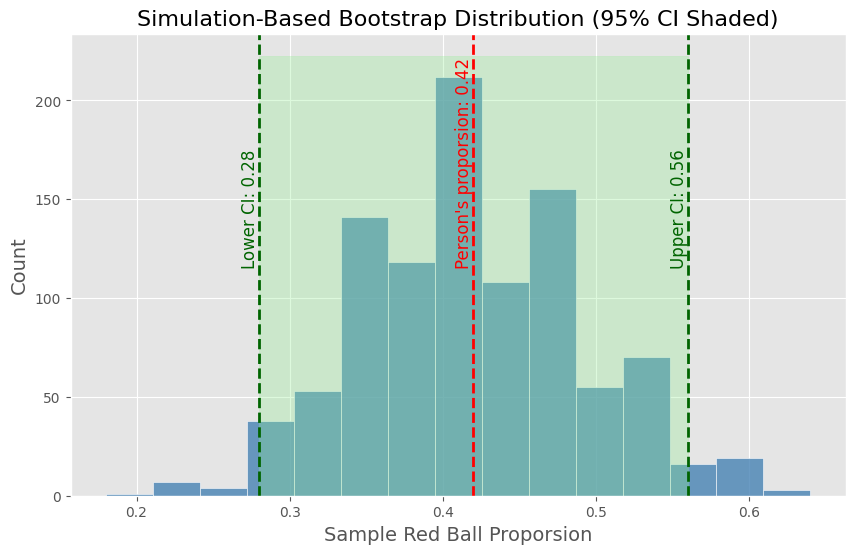

In [ ]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))


ax.hist(bootstrap_distribution_counts['Prop'],
        bins=15,
        edgecolor='white',
        color='steelblue',
        alpha=0.8
        )


ax.axvline(percentile_ci[0], color='darkgreen', linestyle='--', linewidth=2)
ax.axvline(percentile_ci[1], color='darkgreen', linestyle='--', linewidth=2)

ax.axvline(prop, color='red', linestyle='--', linewidth=2)

ax.fill_betweenx(
    y=[0, ax.get_ylim()[1]],
    x1=percentile_ci[0], x2=percentile_ci[1],
    color='lightgreen', alpha=0.3
)

# Adding text labels for the CI values
ax.text(percentile_ci[0], ax.get_ylim()[1] * 0.5, f"Lower CI: {percentile_ci[0]:.2f}", fontsize=12, color='darkgreen', ha='right', rotation = 90)
ax.text(percentile_ci[1], ax.get_ylim()[1] * 0.5, f"Upper CI: {percentile_ci[1]:.2f}", fontsize=12, color='darkgreen', ha='right', rotation = 90)

ax.text(prop, ax.get_ylim()[1] * 0.5, f"Person's proporsion: {prop:.2f}", fontsize=12, color='red', ha='right', rotation = 90)

ax.set_title('Simulation-Based Bootstrap Distribution (95% CI Shaded)', fontsize=16)
ax.set_xlabel('Sample Red Ball Proporsion', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
plt.show()

- Did Sample of the person's net capture the fish?
- Did their 95% confidence interval for  $p$ based on their sample contain the true value of  $p$ of 0.375?
  - Yes!
  - 0.375 is between the endpoints of their confidence interval (0.28, 0.56).




- Now, if we had a different sample of 50 balls and constructed a different confidence interval, would it necessarily contain  $p= 0.375$ as well?
  - For, we generate a random sample of size 50.

In [ ]:
# Enhanced Workflow (infer-like)
sample2 = pd.DataFrame({
    'replicate': np.repeat(np.arange(1, 51), 1),
    'color': np.random.choice(bowl_sample_1_list,
                              size=50 * 1,
                              replace=True)
})
sample2 = sample2['color']
sample2

,color
0,white
1,red
2,red
3,red
4,white
5,red
6,red
7,white
8,red
9,red


In [ ]:
  # Enhanced Workflow (infer-like)
bootstrap_distribution = pd.DataFrame({
    'replicate': np.repeat(np.arange(1, 1001), 50),
    'color': np.random.choice(sample2, size=50 * 1000, replace=True)
})
bootstrap_distribution

,replicate,color
0,1,red
1,1,white
2,1,white
3,1,white
4,1,red
...,...,...
49995,1000,white
49996,1000,red
49997,1000,white
49998,1000,red


In [ ]:
bootstrap_distribution_red = bootstrap_distribution[bootstrap_distribution['color'] == 'red']
bootstrap_distribution_red

,replicate,color
0,1,red
4,1,red
5,1,red
9,1,red
14,1,red
...,...,...
49980,1000,red
49991,1000,red
49994,1000,red
49996,1000,red


In [ ]:
# Calculating the mean for each resample
bootstrap_distribution_counts = (
    bootstrap_distribution_red.groupby('replicate')['color'].count().reset_index(name='count')
)
bootstrap_distribution_counts

,replicate,count
0,1,22
1,2,23
2,3,25
3,4,23
4,5,18
...,...,...
995,996,25
996,997,25
997,998,23
998,999,26


In [ ]:
bootstrap_distribution_counts['Prop'] = bootstrap_distribution_counts['count'] / 50
bootstrap_distribution_counts

,replicate,count,Prop
0,1,22,0.44
1,2,23,0.46
2,3,25,0.50
3,4,23,0.46
4,5,18,0.36
...,...,...,...
995,996,25,0.50
996,997,25,0.50
997,998,23,0.46
998,999,26,0.52


In [ ]:
# Calculating the 95% Confidence Interval using the Percentile Method
percentile_ci = np.percentile(bootstrap_distribution_counts['Prop'], [2.5, 97.5])
percentile_ci

array([0.3 , 0.56])

In [ ]:
print(f"Percentile Method 95% Confidence Interval: Lower CI: {percentile_ci[0]:.2f}, Upper CI: {percentile_ci[1]:.2f}")

Percentile Method 95% Confidence Interval: Lower CI: 0.30, Upper CI: 0.56


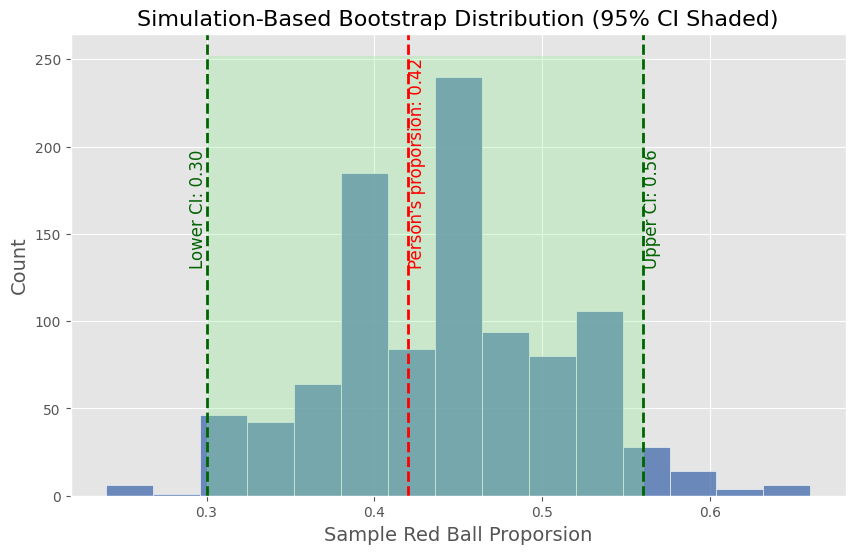

In [ ]:
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))


ax.hist(bootstrap_distribution_counts['Prop'], bins=15, edgecolor='white', color='#4c72b0', alpha=0.8)


ax.axvline(percentile_ci[0], color='darkgreen', linestyle='--', linewidth=2)
ax.axvline(percentile_ci[1], color='darkgreen', linestyle='--', linewidth=2)

ax.axvline(prop, color='red', linestyle='--', linewidth=2)

ax.fill_betweenx(
    y=[0, ax.get_ylim()[1]],
    x1=percentile_ci[0], x2=percentile_ci[1],
    color='lightgreen', alpha=0.3
)

# Adding text labels for the CI values
ax.text(percentile_ci[0], ax.get_ylim()[1] * 0.5, f"Lower CI: {percentile_ci[0]:.2f}", fontsize=12, color='darkgreen', ha='right', rotation = 90)
ax.text(percentile_ci[1], ax.get_ylim()[1] * 0.5, f"Upper CI: {percentile_ci[1]:.2f}", fontsize=12, color='darkgreen', ha='left', rotation = 90)

ax.text(prop, ax.get_ylim()[1] * 0.5, f"Person's proporsion: {prop:.2f}", fontsize=12, color='red', ha='left', rotation = 90)

ax.set_title('Simulation-Based Bootstrap Distribution (95% CI Shaded)', fontsize=16)
ax.set_xlabel('Sample Red Ball Proporsion', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
plt.show()

✨ ✨ Thus, if we had a different sample of 50 balls and constructed a different confidence interval, would it necessarily contain  𝑝=0.42  as well!!!

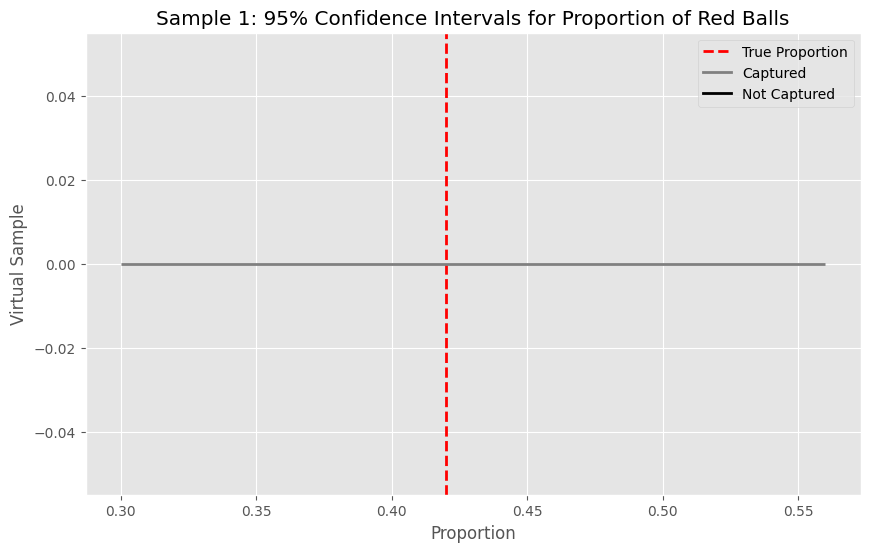

In [ ]:
from matplotlib.lines import Line2D

true_prop = prop # True proportion of red balls
cis_one = []
captures_one = []

cis_one = percentile_ci
captures_one.append(true_prop >= cis_one[0] and true_prop <= cis_one[1])

# Plotting the results
plt.figure(figsize=(10, 6))
plt.axvline(true_prop, color='red', linestyle='--', linewidth=2, label=f'True Proportion: {true_prop:.2f}')

color = 'grey' if captures_one[i] else 'black'
plt.hlines(i, cis_one[0], cis_one[1], color=color, linewidth=2)


# Custom legend for captured and not captured
legend_elements = [
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Proportion'),
    Line2D([0], [0], color='grey', lw=2, label='Captured'),
    Line2D([0], [0], color='black', lw=2, label='Not Captured'),
]

plt.xlabel("Proportion")
plt.ylabel("Virtual Sample")
plt.title("Sample 1: 95% Confidence Intervals for Proportion of Red Balls")
plt.legend(handles=legend_elements)
plt.show()

### Now repeat this process 10 times, then 100 more times:
  - we take 10 first (then 100) virtual samples from the bowl
  - construct 10 first (then 100) 95% confidence intervals.

In [ ]:
prop

0.42

In [ ]:
# Function to create a confidence interval for a given sample - Percentile method
def create_ci(sample, prop):
    bootstrap_distribution = pd.DataFrame({
        'replicate': np.repeat(np.arange(1, 1001), len(sample)),
        'color': np.random.choice(sample, size=len(sample) * 1000, replace=True)
    })
    bootstrap_distribution_red = bootstrap_distribution[bootstrap_distribution['color'] == 'red']
    bootstrap_distribution_counts = (
        bootstrap_distribution_red.groupby('replicate')['color'].count().reset_index(name='count')
    )
    bootstrap_distribution_counts['Prop'] = bootstrap_distribution_counts['count'] / len(sample)
    percentile_ci = np.percentile(bootstrap_distribution_counts['Prop'], [2.5, 97.5])
    return percentile_ci

In [ ]:
path = 'https://raw.githubusercontent.com/tec03/Datasets/refs/heads/main/datasets/bowl_sample_1.csv'
bowl_sample_1 = pd.read_csv(path)
bowl_sample_1.head()

,color
0,white
1,white
2,red
3,red
4,white


In [ ]:
bowl_sample_1_red = bowl_sample_1[bowl_sample_1['color'] == 'red']
bowl_sample_1_red
prop = len(bowl_sample_1_red)/len(bowl_sample_1)
print(f"The population proportion of the Sample 1 is : {prop}")

The population proportion of the Sample 1 is : 0.42


In [ ]:
bowl_sample_1_list = bowl_sample_1['color'].tolist()
bowl_sample_1_list

['white',
 'white',
 'red',
 'red',
 'white',
 'white',
 'red',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'red',
 'red',
 'white',
 'red',
 'red',
 'white',
 'white',
 'red',
 'white',
 'white',
 'red',
 'white',
 'red',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'white',
 'red',
 'red',
 'red',
 'red',
 'red',
 'white',
 'red',
 'white',
 'red',
 'white',
 'red',
 'white',
 'red',
 'red',
 'red',
 'white']

In [ ]:
num_samples = 100 # Number of virtual samples

true_prop = prop # True proportion of red balls

# Store confidence intervals and capture information
cis = []
captures = []

# Create num_samples virtual samples and confidence intervals
for _ in range(num_samples):
    virtual_sample = np.random.choice(bowl_sample_1_list,
                                      size=50,
                                      replace=True
                                      )

    virtual_sample_df = pd.DataFrame({'color': virtual_sample})

    virtual_sample = virtual_sample_df['color'].tolist()

    ci = create_ci(virtual_sample, true_prop)

    cis.append(ci)

    captures.append(true_prop >= ci[0] and true_prop <= ci[1])

In [ ]:
virtual_sample # only last one is saved in this variable

['white',
 'white',
 'white',
 'white',
 'white',
 'red',
 'red',
 'white',
 'white',
 'red',
 'red',
 'white',
 'red',
 'white',
 'white',
 'red',
 'white',
 'red',
 'red',
 'white',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'red',
 'white',
 'white',
 'white',
 'white',
 'white',
 'red',
 'white',
 'white',
 'white',
 'red',
 'white',
 'white',
 'white',
 'red',
 'white',
 'red',
 'red',
 'white',
 'white',
 'white',
 'red']

In [ ]:
virtual_sample_df # only last one is saved in this variable

,color
0,white
1,white
2,white
3,white
4,white
5,red
6,red
7,white
8,white
9,red


In [ ]:
ci # only last one is saved in this variable

array([0.32, 0.6 ])

In [ ]:
cis # Each iteration is saved in this variable

[array([0.36, 0.64]),
 array([0.32, 0.58]),
 array([0.32, 0.6 ]),
 array([0.24  , 0.4805]),
 array([0.24, 0.52]),
 array([0.3395, 0.6   ]),
 array([0.32, 0.6 ]),
 array([0.32, 0.58]),
 array([0.36, 0.64]),
 array([0.26, 0.54]),
 array([0.22, 0.48]),
 array([0.32, 0.6 ]),
 array([0.34, 0.6 ]),
 array([0.28, 0.56]),
 array([0.24  , 0.5205]),
 array([0.22, 0.48]),
 array([0.28, 0.54]),
 array([0.28, 0.56]),
 array([0.24, 0.52]),
 array([0.3 , 0.56]),
 array([0.18  , 0.4205]),
 array([0.24, 0.52]),
 array([0.26, 0.54]),
 array([0.38, 0.66]),
 array([0.24, 0.52]),
 array([0.22, 0.48]),
 array([0.32, 0.58]),
 array([0.26, 0.52]),
 array([0.28, 0.56]),
 array([0.38, 0.68]),
 array([0.34, 0.62]),
 array([0.3 , 0.56]),
 array([0.24, 0.52]),
 array([0.32, 0.6 ]),
 array([0.22, 0.48]),
 array([0.34, 0.6 ]),
 array([0.28, 0.56]),
 array([0.22, 0.5 ]),
 array([0.32, 0.6 ]),
 array([0.28, 0.56]),
 array([0.3 , 0.58]),
 array([0.3195, 0.6   ]),
 array([0.4 , 0.68]),
 array([0.3 , 0.58]),
 array([0.26

In [ ]:
captures # True if true_prop intersects with this ci

[np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.False_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_,
 np.True_

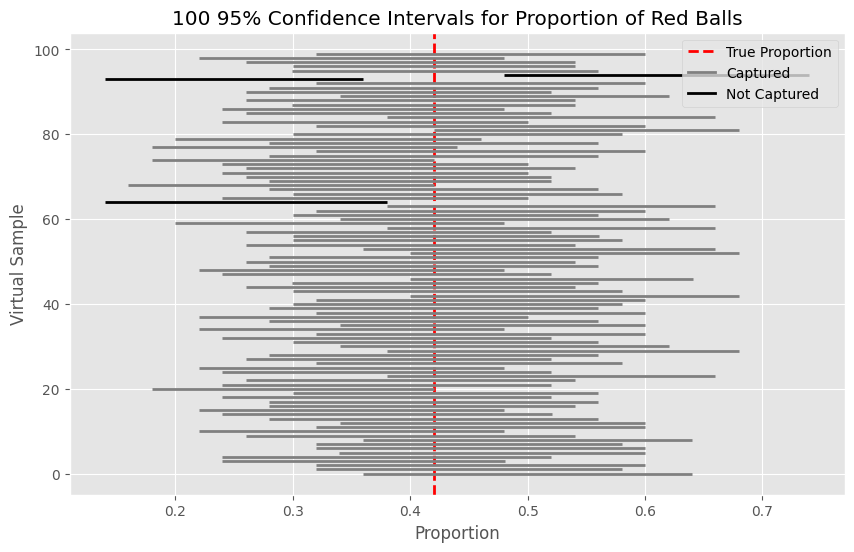

In [ ]:
from matplotlib.lines import Line2D

# Plotting the results
plt.figure(figsize=(10, 6))
plt.axvline(true_prop, color='red', linestyle='--', linewidth=2, label=f'True Proportion: {true_prop:.2f}')

for i, ci in enumerate(cis):
    color = 'grey' if captures[i] else 'black'
    plt.hlines(i, ci[0], ci[1], color=color, linewidth=2)


# Custom legend for captured and not captured
legend_elements = [
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Proportion'),
    Line2D([0], [0], color='grey', lw=2, label='Captured'),
    Line2D([0], [0], color='black', lw=2, label='Not Captured'),
]

plt.xlabel("Proportion")
plt.ylabel("Virtual Sample")
plt.title("100 95% Confidence Intervals for Proportion of Red Balls")
plt.legend(handles=legend_elements)
plt.show()


In [ ]:
win_rate = (sum(captures)/len(cis))*100
win_rate

np.float64(97.0)

In [ ]:
print(f"Win rate: {win_rate:.2f}%")

Win rate: 97.00%


In other words, 92% (win_rate) of the time,  our nets caught the fish, whereas 8% of our nets didn’t!. (We used the Percentile method to calculate teh CIs)

- Re-run this section now with 100 - num_samples = 100

### 2. Confidence Intervals Using the Standard Error Method

> Bootstrap resampling provides a computational way to quantify uncertainty.

Before computers became widely available, statisticians often relied on the **Standard Error (SE)** to estimate uncertainty analytically.

Both approaches attempt to answer the same question:

> How much should we trust our estimate?

Sample ->  Estimate ->  Standard Error ->  Confidence Interval -> Uncertainty Quantification

The Standard Error method is one of the foundational tools in statistics and forms the basis for many uncertainty estimates used in modern machine learning and AI.

In [ ]:
# Function to create a confidence interval for a given sample - Standard Error method
def create_ci_se(sample, prop):
    bootstrap_distribution = pd.DataFrame({
        'replicate': np.repeat(np.arange(1, 1001), len(sample)),
        'color': np.random.choice(sample, size=len(sample) * 1000, replace=True)
    })
    bootstrap_distribution_red = bootstrap_distribution[bootstrap_distribution['color'] == 'red']
    bootstrap_distribution_counts = (
        bootstrap_distribution_red.groupby('replicate')['color'].count().reset_index(name='count')
    )
    bootstrap_distribution_counts['Prop'] = bootstrap_distribution_counts['count'] / len(sample)
    sample_mean = bootstrap_distribution_counts['Prop'].mean()
    standard_error = bootstrap_distribution_counts['Prop'].std()
    ci_lower = sample_mean - 1.282 * standard_error  # this 1.96 - because 95% CI
    ci_upper = sample_mean + 1.282 * standard_error  # this 1.96 - because 95% CI
    return (ci_lower, ci_upper)

In [ ]:
path = 'https://raw.githubusercontent.com/tec03/Datasets/refs/heads/main/datasets/bowl_sample_1.csv'
bowl_sample_1 = pd.read_csv(path)
bowl_sample_1_red = bowl_sample_1[bowl_sample_1['color'] == 'red']
prop = len(bowl_sample_1_red) / len(bowl_sample_1)
bowl_sample_1_list = bowl_sample_1['color'].tolist()

In [ ]:
num_samples = 100  # Number of virtual samples
true_prop = prop  # True proportion of red balls

cis = []
captures = []

for _ in range(num_samples):
    virtual_sample = np.random.choice(bowl_sample_1_list, size=50, replace=True)
    virtual_sample_df = pd.DataFrame({'color': virtual_sample})
    virtual_sample = virtual_sample_df['color'].tolist()
    ci = create_ci_se(virtual_sample, true_prop)
    cis.append(ci)
    captures.append(true_prop >= ci[0] and true_prop <= ci[1])

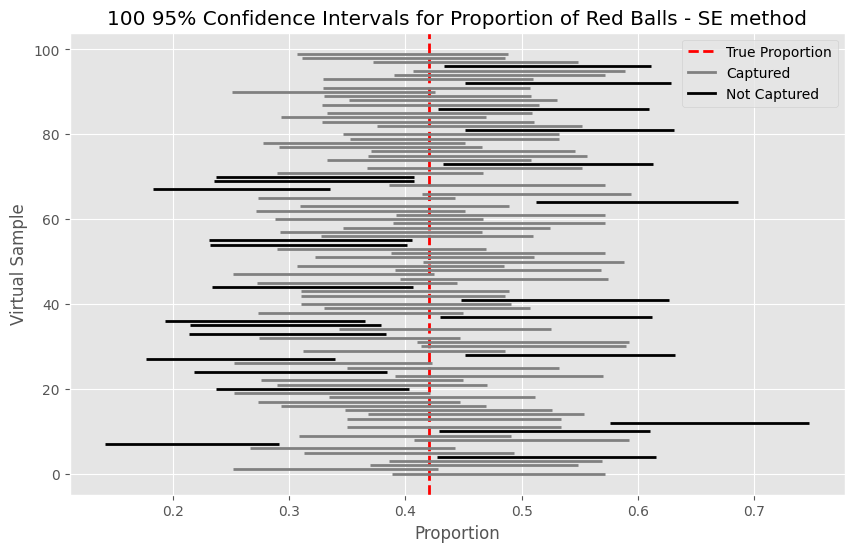

Win rate: 75.00%


In [ ]:
plt.figure(figsize=(10, 6))
plt.axvline(true_prop, color='red', linestyle='--', linewidth=2, label=f'True Proportion: {true_prop:.2f}')
for i, ci in enumerate(cis):
    color = 'grey' if captures[i] else 'black'
    plt.hlines(i, ci[0], ci[1], color=color, linewidth=2)

legend_elements = [
    Line2D([0], [0], color='red', linestyle='--', lw=2, label='True Proportion'),
    Line2D([0], [0], color='grey', lw=2, label='Captured'),
    Line2D([0], [0], color='black', lw=2, label='Not Captured'),
]
plt.xlabel("Proportion")
plt.ylabel("Virtual Sample")
plt.title("100 95% Confidence Intervals for Proportion of Red Balls - SE method")
plt.legend(handles=legend_elements)
plt.show()

win_rate = (sum(captures) / len(cis)) * 100
print(f"Win rate: {win_rate:.2f}%")


In [ ]:
from scipy.stats import norm

# Function to calculate the critical value (Z) for any confidence level
def get_critical_value(confidence_level):
    alpha = 1 - confidence_level
    z_value = norm.ppf(1 - alpha / 2)
    return z_value


ci_80 = get_critical_value(0.80)
ci_90 = get_critical_value(0.90)
ci_95 = get_critical_value(0.95)
ci_99 = get_critical_value(0.99)

print(f"80% CI Critical Value (Z): ±{ci_80:.3f}")
print(f"90% CI Critical Value (Z): ±{ci_90:.3f}")
print(f"95% CI Critical Value (Z): ±{ci_95:.3f}")
print(f"99% CI Critical Value (Z): ±{ci_99:.3f}")

80% CI Critical Value (Z): ±1.282
90% CI Critical Value (Z): ±1.645
95% CI Critical Value (Z): ±1.960
99% CI Critical Value (Z): ±2.576


Why the *80% Confidence Interval (CI)* Has a Lower Win Rate:

* The *win_rate* here means the probability that the confidence interval captures the true population parameter.
* An *80% CI* is *narrower* than a 95% or 99% CI because it covers only the *middle 80%* of the distribution.
* This means it is *more precise* (narrower range) but has a *higher chance of missing* the true parameter.

* A *95% CI* is calculated using:

  $$
  \bar{x} \pm 1.96 \times SE
  $$

  This means it captures the middle *95%* of the bootstrap distribution, leaving *2.5% in each tail*.

* An *80% CI* is calculated using:

  $$
  \bar{x} \pm 1.282 \times SE
  $$

  This means it captures only the middle *80%* of the distribution, leaving *10% in each tail*.


In a simulation, an 80% CI will capture the true value in only 80% of trials on average, while a 95% CI will capture it in 95% of trials.


Precise and shorthand interpretation:
  - If we repeated our sampling procedure a large number of times, we expect about 95% of the resulting confidence intervals to capture the value of the population parameter.
  - We can expect our confidence intervals to include the true population parameter about 95% of the time.
  - We are 95% “confident” that a 95% confidence interval captures the value of the population parameter.


  >Conclusion on pennies : We are 95% “confident” that the true mean year of pennies in circulation in 2019 is somewhere between 1991.24 and 1999.42.

In [ ]:

from scipy.stats import norm

# Function to calculate the critical value (Z) for any confidence level
def get_critical_value(confidence_level):
    alpha = 1 - confidence_level
    z_value = norm.ppf(1 - alpha / 2)
    return z_value

# Function to create a confidence interval using the standard error method
def create_ci_se(sample, confidence_level):
    bootstrap_distribution = pd.DataFrame({
        'replicate': np.repeat(np.arange(1, 1001), len(sample)),
        'color': np.random.choice(sample, size=len(sample) * 1000, replace=True)
    })
    bootstrap_distribution_red = bootstrap_distribution[bootstrap_distribution['color'] == 'red']
    bootstrap_distribution_counts = (
        bootstrap_distribution_red.groupby('replicate')['color'].count().reset_index(name='count')
    )
    bootstrap_distribution_counts['Prop'] = bootstrap_distribution_counts['count'] / len(sample)
    sample_mean = bootstrap_distribution_counts['Prop'].mean()
    standard_error = bootstrap_distribution_counts['Prop'].std()
    critical_value = get_critical_value(confidence_level)
    ci_lower = sample_mean - critical_value * standard_error
    ci_upper = sample_mean + critical_value * standard_error
    return (ci_lower, ci_upper)

# Load bowl data
bowl_data = 'https://raw.githubusercontent.com/tec03/Datasets/refs/heads/main/datasets/bowl_n.csv'
bowl = pd.read_csv(bowl_data)
bowl_red = bowl[bowl['color'] == 'red']
true_prop = len(bowl_red) / len(bowl)

# Load sample data
path = 'https://raw.githubusercontent.com/tec03/Datasets/refs/heads/main/datasets/bowl_sample_1.csv'
bowl_sample_1 = pd.read_csv(path)
bowl_sample_1_list = bowl_sample_1['color'].tolist()


confidence_levels = [0.80, 0.90, 0.95, 0.99]
num_samples = 30

for confidence_level in confidence_levels:
    cis = []
    for _ in range(num_samples):
        virtual_sample = np.random.choice(bowl_sample_1_list, size=50, replace=True)
        ci = create_ci_se(virtual_sample, confidence_level)
        cis.append(ci)

    #Here you would add code to calculate the widths and visualize the intervals.
    # Example:
    widths = [ci[1]-ci[0] for ci in cis]
    print(f"Confidence Level: {confidence_level*100}%")
    print(f"Average Width: {np.mean(widths)}")
    # Add your visualization code here (matplotlib, etc.)



Confidence Level: 80.0%
Average Width: 0.17537831845255544
Confidence Level: 90.0%
Average Width: 0.22595604975343192
Confidence Level: 95.0%
Average Width: 0.27098615788212166
Confidence Level: 99.0%
Average Width: 0.35558501729126246


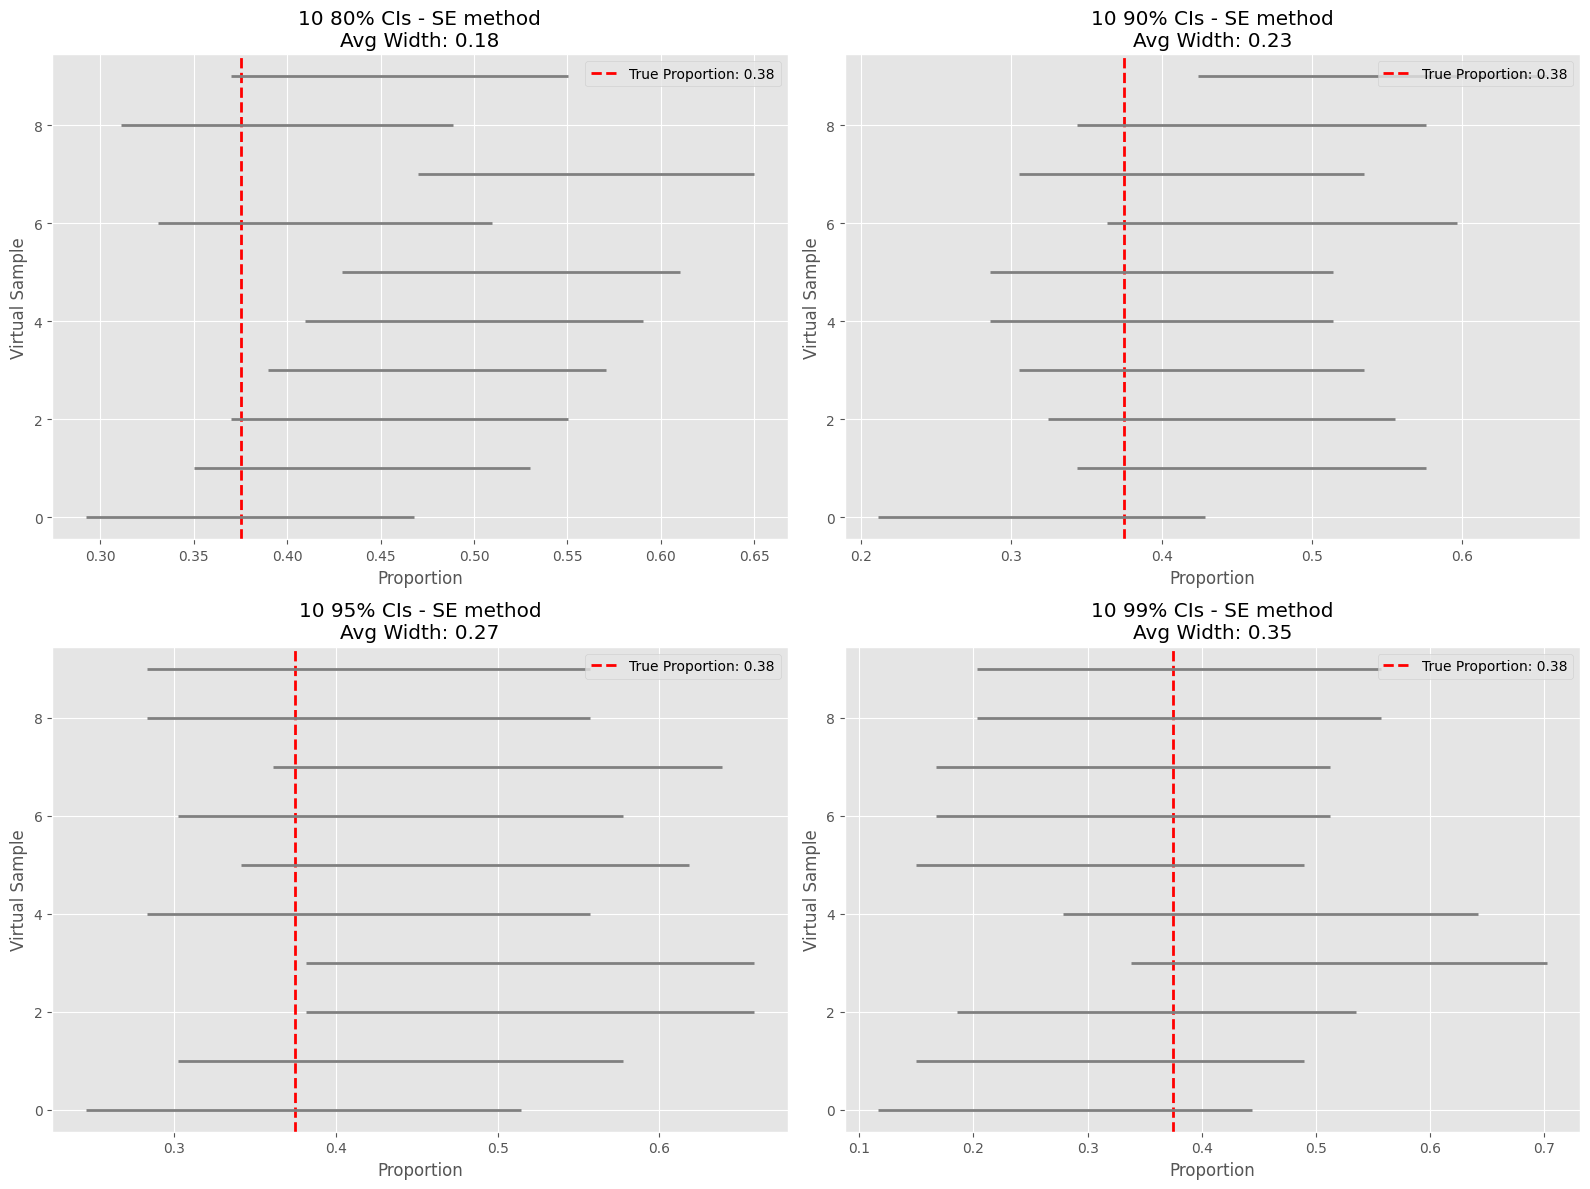

In [ ]:
from scipy.stats import norm

# Function to create confidence intervals using Standard Error Method
def create_ci_se(sample, confidence_level):
    sample_prop = np.sum(sample == 'red') / len(sample)
    se = np.sqrt((sample_prop * (1 - sample_prop)) / len(sample))
    z_value = norm.ppf(1 - (1 - confidence_level) / 2)
    lower_ci = sample_prop - z_value * se
    upper_ci = sample_prop + z_value * se
    return lower_ci, upper_ci

# # Sample data
# bowl_sample_1_list = ['red'] * 30 + ['blue'] * 20  # 30 red, 20 blue
# true_prop = 0.6  # True proportion of red balls

# Confidence Levels and Matrix Setup
confidence_levels = [0.80, 0.90, 0.95, 0.99]
num_samples = 10
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.ravel()  # Flattening the 2x2 grid

# Looping through each confidence level
for idx, confidence_level in enumerate(confidence_levels):
    cis = []
    widths = []

    for _ in range(num_samples):
        virtual_sample = np.random.choice(bowl_sample_1_list, size=50, replace=True)
        virtual_sample = np.array(virtual_sample)
        ci = create_ci_se(virtual_sample, confidence_level)
        cis.append(ci)
        widths.append(ci[1] - ci[0])

    # Plotting each subplot
    ax = axs[idx]
    ax.axvline(true_prop, color='red', linestyle='--', linewidth=2, label=f'True Proportion: {true_prop:.2f}')


    for i, ci in enumerate(cis):
        ax.hlines(i, ci[0], ci[1], color='grey', linewidth=2)

    ax.set_xlabel("Proportion")
    ax.set_ylabel("Virtual Sample")
    ax.set_title(f"{num_samples} {int(confidence_level * 100)}% CIs - SE method\nAvg Width: {np.mean(widths):.2f}")
    ax.legend()

plt.tight_layout()
plt.show()


Higher confidence levels tend to produce wider confidence intervals.

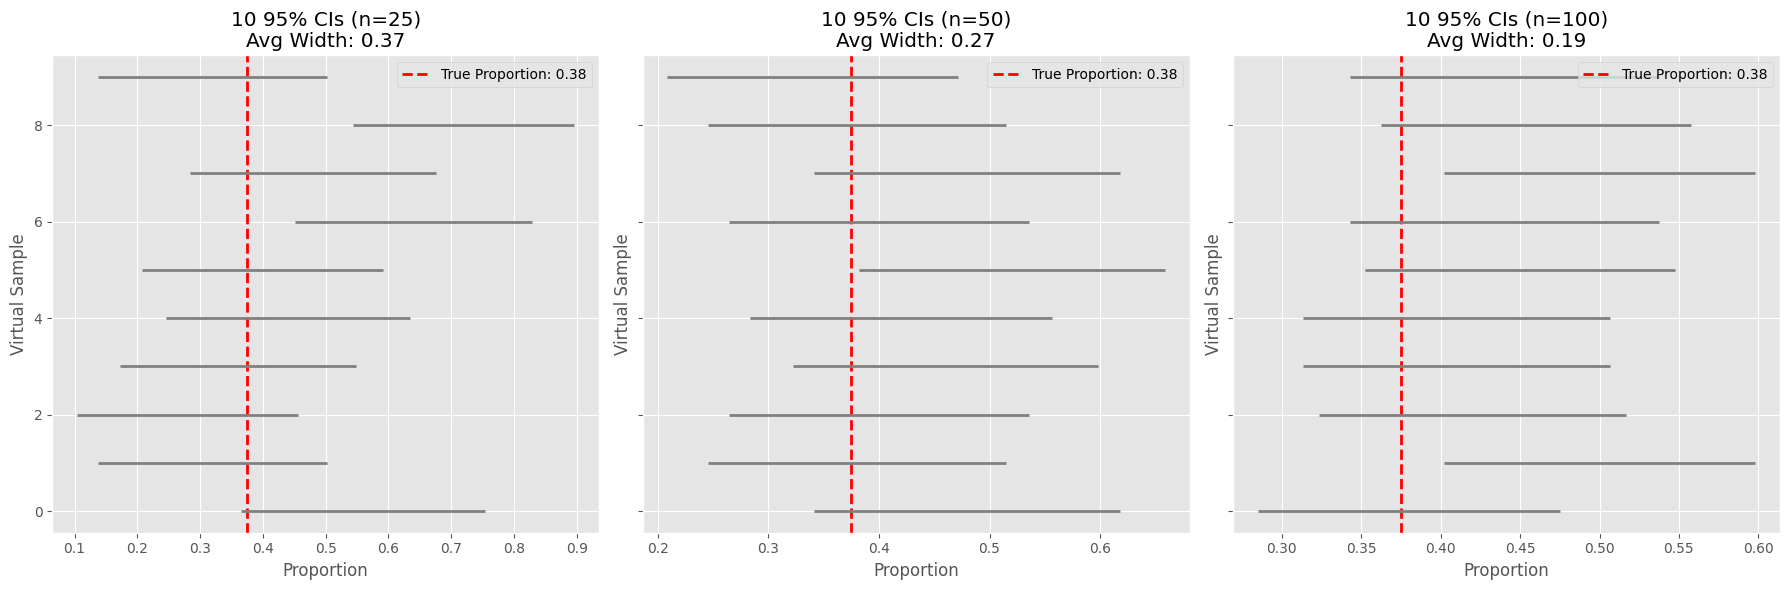

In [ ]:
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Function to create confidence intervals using Standard Error Method
def create_ci_se(sample, confidence_level):
    sample_prop = np.sum(sample == 'red') / len(sample)
    se = np.sqrt((sample_prop * (1 - sample_prop)) / len(sample))
    z_value = norm.ppf(1 - (1 - confidence_level) / 2)
    lower_ci = sample_prop - z_value * se
    upper_ci = sample_prop + z_value * se
    return lower_ci, upper_ci


# Sample sizes to consider
sample_sizes = [25, 50, 100]
confidence_level = 0.95
num_samples_per_size = 10

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)  # Create 3 subplots
for i, sample_size in enumerate(sample_sizes):
  cis = []
  widths = []
  for _ in range(num_samples_per_size):
    virtual_sample = np.random.choice(bowl_sample_1_list, size=sample_size, replace=True)
    virtual_sample = np.array(virtual_sample)
    ci = create_ci_se(virtual_sample, confidence_level)
    cis.append(ci)
    widths.append(ci[1]-ci[0])

  ax = axes[i]  # Select the current subplot
  ax.axvline(true_prop, color='red', linestyle='--', linewidth=2, label=f'True Proportion: {true_prop:.2f}')

  for j, ci in enumerate(cis):
    ax.hlines(j, ci[0], ci[1], color='grey', linewidth=2)

  ax.set_xlabel("Proportion")
  ax.set_ylabel("Virtual Sample")
  ax.set_title(f"{num_samples_per_size} {int(confidence_level * 100)}% CIs (n={sample_size})\nAvg Width: {np.mean(widths):.2f}")
  ax.legend()

plt.tight_layout()
plt.show()


Larger sample sizes tend to produce narrower confidence intervals.

# 9. Bootstrapping in AI: Random Forests

Until now, we used bootstrapping to estimate uncertainty.

However, bootstrapping is also a core component of one of the most successful machine learning algorithms ever developed:

Random Forest.

Random Forest does not use bootstrap resampling to estimate confidence intervals.

Instead, it uses bootstrap resampling to create many different training datasets.

Each bootstrap dataset trains a different decision tree.

The predictions of all trees are then combined.

This process improves generalization and reduces overfitting.



In statistics:


Bootstrap ->  Distribution of estimates -> Confidence Interval


In AI:

Bootstrap -> Many training datasets -> Many decision trees -> Ensemble prediction


Same idea: Different objective.

### Visualization:

Original Training Data

            ▼

     Bootstrap #1
            │
        Tree #1

     Bootstrap #2
            │
        Tree #2

     Bootstrap #3
            │
        Tree #3

     Bootstrap #4
            │
        Tree #4

            .
            .
            .

        Aggregate

            ▼

     Random Forest

Suppose our bowl sample contains: 50 balls

Bootstrap creates:
- Sample A
- Sample B
- Sample C
- Sample D
- ...

All slightly different.

This variability allowed us to estimate uncertainty.

Now imagine:

- Instead of estimating a proportion, each resampled dataset trains a decision tree.

- Now variability becomes diversity. And diversity is exactly what Random Forest needs.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100, #Build 100 decision trees.
    bootstrap=True,
    random_state=42 #Python starts the random number generator from the same place every time.
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

accuracy_score(y_test, pred)

0.9707602339181286

In [ ]:
rf.bootstrap # What is the value of the bootstrap parameter inside this Random Forest model?


True

### Why Bootstrap?

| Method       | Assumptions                 |
| ------------ | --------------------------- |
| Classical CI | Often needs normality       |
| Jackknife    | Fewer assumptions           |
| Bootstrap    | Very few assumptions        |
| Bayesian     | Requires prior distribution |


- In the 20th century, statisticians often relied on formulas.
- In the 21st century, with powerful computers, we can let the computer approximate uncertainty through resampling.
- Bootstrapping is one of the best examples of this shift from mathematical derivation to computational statistics.

### Every tree in this forest was trained using a bootstrap sample.

- A Decision Tree is a high-variance learner.

- Small changes in the training data can produce very different trees.

- Bootstrapping intentionally creates many slightly different versions of the training dataset.

- Each bootstrap sample produces a different tree.

- Random Forest combines all these trees through voting (classification) or averaging (regression).

- The averaging process reduces variance and improves prediction performance.

The bowl taught us:

One sample -> Many bootstrap samples -> Sampling variability -> Confidence interval


Random Forest teaches:
One dataset  ->  Many bootstrap datasets -> Better predictions

## Key Takeaways

- Probability is about uncertainty.
- Bootstrapping estimates uncertainty without knowing the population distribution.
- Confidence intervals quantify uncertainty in estimates.
- The same bootstrap idea powers Random Forests.
- Bootstrapping is therefore both:
    - a statistical tool
    - an AI tool